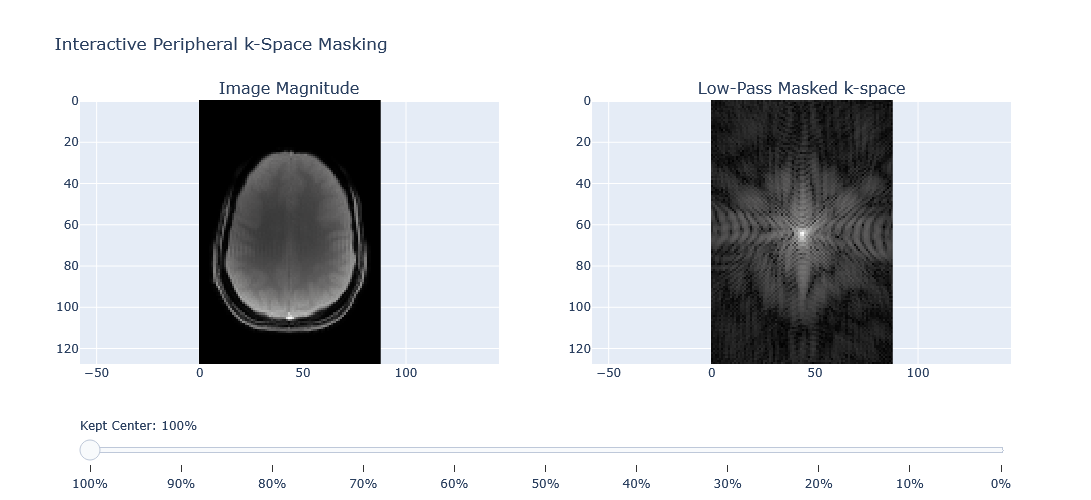

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Load the k-space data
k_space = np.load('kspace_combined.npy')
rows, cols = k_space.shape
center_r, center_c = rows // 2, cols // 2

# 2. Initialize Plotly subplots
fig = make_subplots(rows=1, cols=2, subplot_titles=("Image Magnitude", "Low-Pass Masked k-space"))
frames = []
steps = []

# 3. Pre-calculate frames for different mask sizes (100% down to 10% kept)
mask_percentages = range(100, -1, -10)

for i, p in enumerate(mask_percentages):
    # Create a mask of zeros (blocking everything)
    mask = np.zeros((rows, cols))
    if p > 0:
        # Calculate the dimensions of the central region to KEEP
        dr = int(rows * (p / 100) / 2)
        dc = int(cols * (p / 100) / 2)
        # Set the central region to 1 (keep these frequencies)
        mask[center_r - dr : center_r + dr, center_c - dc : center_c + dc] = 1
        
    # Apply the mask to k-space
    k_space_masked = k_space * mask
    
    # Transform back to image space 
    img_masked = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_space_masked)))
    img_mag = np.abs(img_masked)
    
    # Logarithmic transformation for k-space visualization 
    k_space_log = np.log(np.abs(k_space_masked) + 1e-5)
    
    # Add the initial traces (Frame 0, representing 100% kept)
    if i == 0:
        fig.add_trace(go.Heatmap(z=img_mag, colorscale='gray', showscale=False), row=1, col=1)
        fig.add_trace(go.Heatmap(z=k_space_log, colorscale='gray', showscale=False), row=1, col=2)
        
    # Append a new frame for the current mask size
    frames.append(go.Frame(data=[go.Heatmap(z=img_mag), go.Heatmap(z=k_space_log)], name=str(p)))
    
    # Configure the slider step for this frame
    step = dict(
        method="animate",
        args=[[str(p)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True}, "transition": {"duration": 0}}],
        label=f"{p}%"
    )
    steps.append(step)

# 4. Apply layout, slider, and fix the aspect ratio
fig.frames = frames
sliders = [dict(
    active=0,
    currentvalue={"prefix": "Kept Center: "},
    pad={"t": 50},
    steps=steps
)]

fig.update_layout(
    sliders=sliders, 
    height=500, 
    title="Interactive Peripheral k-Space Masking",
    yaxis=dict(scaleanchor="x", autorange="reversed"),
    yaxis2=dict(scaleanchor="x2", autorange="reversed")
)

# 5. Visualize the interactive plot
fig.show()